# Playground for material data

In [15]:
import pandas as pd
from pymatgen.core import Structure
from pymatgen.vis.structure_vtk import StructureVis  # needs vtk
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
from src.dataLib.realCrystal import CrystalDataset
from src.dataLib.preprocessCSV import preprocess_matcsv
import src.dataLib.transform as T
import torch_geometric.transforms as PyGT
from torch_geometric.loader import DataLoader as PyGDataLoader
import os

from src.diffusion.tdm import TDMDiffusion
from src.diffusion.kldm import KLDM
from src.diffusion.continuous import ContinuousDiffusion
from src.diffusion.sde import VPSDE, LinearSchedule
import torch

import matplotlib.pyplot as plt
import nglview as nv
from src.dataLib.data_util import PyGData_to_AseAtoms, PyGData_to_Structure, kldm_output_to_structures_batch, kldm_output_to_structures_one


Preprocess Carbon-24 CSV files

In [16]:
# preprocess the csv file
data_folder = "data/mp-20"
preprocess_matcsv(csv_folder=data_folder, splits=["train", "val", "test"])


  0%|          | 0/3 [00:00<?, ?it/s]/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/Users/jizho/project

KeyboardInterrupt: 

Instantiate the Crystaline pytorch dataset 

In [17]:
transform_lengths = T.ContinuousIntervalLengths(in_key="lengths", out_key="lengths", lengths_loc_scale= f"{data_folder}/train_mean_std_stats.json")
transform_angles = T.ContinuousIntervalAngles(in_key="angles", out_key="angles",angles_loc_scale= (0.0, 0.35) )
transform_pos = T.Pos2Angle(in_key="pos", out_key="pos")
transform = PyGT.Compose([
    transform_lengths,
    transform_angles,
    T.FullyConnectedGraph(key="edge_index", len_from="pos"),
    transform_pos,
    T.ConcatFeatures(in_keys=["lengths", "angles"], out_key="l") # this is the lattices vector of the crystal (a,b,c,alpha,beta,gamma)
])
carbon_24_train = CrystalDataset(path=os.path.join(data_folder, "train.pt"), transform=transform)
carbon_24_train_loader = PyGDataLoader(carbon_24_train, batch_size=12, shuffle=True)
batch = next(iter(carbon_24_train_loader))
print(batch[5].x)
print(batch[5].l)
structure = kldm_output_to_structures_one(batch[5], batch[5].l, batch[5].x, transform_lengths, transform_angles, transform_pos)
print(structure.lattice.parameters)
atoms = PyGData_to_AseAtoms(batch[5], transform_lengths, transform_angles, transform_pos)
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer

Reading 'lengths_loc_scale' from 'data/mp-20/train_mean_std_stats.json'...


/Users/jizho/project_codes/diffusion-playground/src/dataLib/realCrystal.py:27: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  return fs.torch_load(path)


tensor([[ 1.3323e-15, -1.3323e-15,  0.0000e+00],
        [-3.1416e+00, -3.1416e+00, -3.1416e+00],
        [-1.5708e+00, -1.5708e+00, -1.5708e+00],
        [ 1.5708e+00,  1.5708e+00,  1.5708e+00]], dtype=torch.float64)
tensor([[ 0.0482, -0.0307, -0.7836, -1.6496, -1.6496, -1.6496]],
       dtype=torch.float64)
(4.572350219277192, 4.572350396376571, 4.572350689284294, 59.99999999999999, 59.99999999999999, 59.99999999999999)


NGLWidget()

In [18]:

device = "cuda" if torch.cuda.is_available() else "mps"

diffusion_f = TDMDiffusion(
    dim=3, 
    integrator_type="Euler", 
    trunc_n=13, 
    f_scale=2*torch.pi, 
    total_time=2.0, 
    simplified_param=True, 
    n_sigma_rs=2000, 
    zero_cog=True)

l_sde = VPSDE(schedule=LinearSchedule(beta_min=0.1, beta_max=20.0))
diffusion_l = ContinuousDiffusion(sde=l_sde)

kldm = KLDM(
    l_diffusion=diffusion_l,
    f_diffusion=diffusion_f,
    h_diffusion=None,
    total_time=2.0,
)
print(batch)
noised_sample_batch, score_batch, t_batch = kldm.sample_forward(batch)
print(score_batch["l"][1])
print(score_batch["f"].shape)


DataBatch(pos=[113, 3], h=[113], lengths=[12, 3], angles=[12, 3], edge_index=[2, 1248], l=[12, 6], x=[113, 3], batch=[113], ptr=[13])
tensor([[-1.5855],
        [-0.8106],
        [-1.7654],
        [ 0.3264],
        [-3.7067],
        [ 2.1661]], dtype=torch.float64)
torch.Size([113, 3])


Visualize the noised data, fractional coordinates

DataBatch(pos=[113, 3], h=[113], lengths=[12, 3], angles=[12, 3], edge_index=[2, 1248], l=[12, 6], x=[113, 3], batch=[113], ptr=[13], edge_attr=[1248, 3])
torch.Size([12, 6])


/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_92809/1617124600.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(noised_graph_batch[1].x[:,0], noised_graph_batch[1].x[:,1], noised_graph_batch[1].x[:,2], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_92809/1617124600.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(batch[1].x[:,0], batch[1].x[:,1], batch[1].x[:,2], c="red", cmap="viridis")


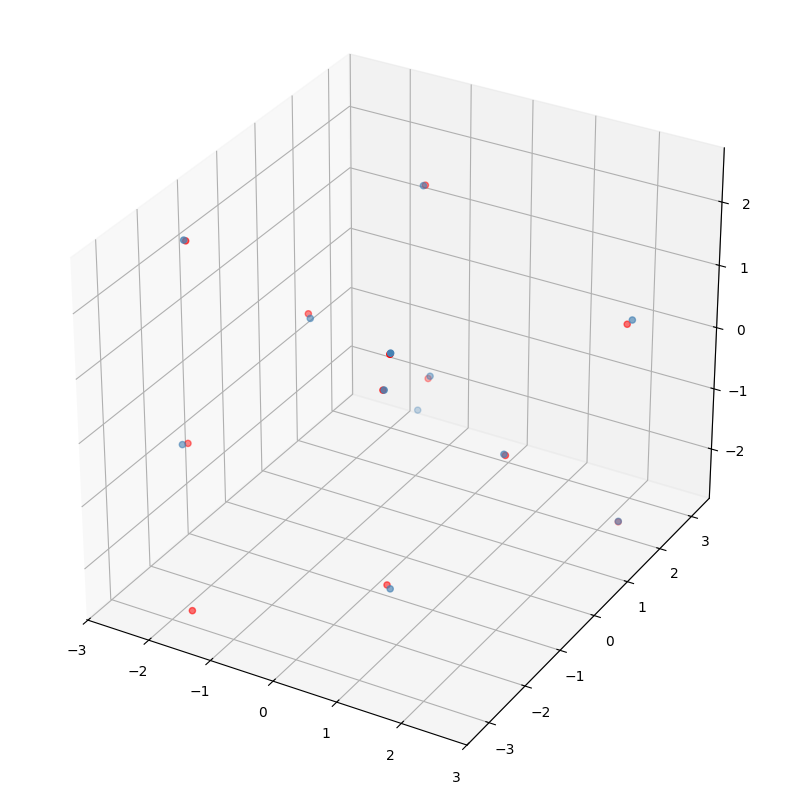

NGLWidget()

In [19]:
vt_batch, noised_graph_batch = noised_sample_batch

print(noised_graph_batch)
print(noised_graph_batch.l.shape)
# visualize the noised points and the original points in 3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(noised_graph_batch[1].x[:,0], noised_graph_batch[1].x[:,1], noised_graph_batch[1].x[:,2], c="steelblue", cmap="viridis")
ax.scatter(batch[1].x[:,0], batch[1].x[:,1], batch[1].x[:,2], c="red", cmap="viridis")
# ax.scatter(vt_batch[:,0], vt_batch[:,1], c="green", cmap="viridis")
ax.set_aspect("equal")
plt.show()

# visualize the noised lattices and the original lattices


structure = kldm_output_to_structures_one(noised_graph_batch[5], noised_graph_batch[5].l, noised_graph_batch[5].x, transform_lengths, transform_angles, transform_pos)
atoms = PyGData_to_AseAtoms(noised_graph_batch[5], transform_lengths, transform_angles, transform_pos)
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer




In [20]:
structure = kldm_output_to_structures_one(batch[5], batch[5].l, batch[5].x, transform_lengths, transform_angles, transform_pos)
atoms = PyGData_to_AseAtoms(batch[5], transform_lengths, transform_angles, transform_pos)
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer

NGLWidget()

# Generate crystals from a trained checkpoint

Load a trained `LitCSPVNet` checkpoint, run the reverse (denoising) KLDM process
to sample new lattices + fractional coordinates conditioned on given atom types,
then reconstruct and visualize the generated crystals.

In [21]:
import glob

from src.nn.CSPVNet import CSPVNet
from src.lit.litCSPVNet import LitCSPVNet

# Reverse-diffusion sampling on CPU is robust and only needs a handful of steps
# per crystal. (MPS/CUDA also work; on Apple Silicon set
# PYTORCH_ENABLE_MPS_FALLBACK=1 as some TDM ops lack MPS kernels.)
gen_device = torch.device("cpu")

# Rebuild the network exactly as configured in src/litTrain/trainLitKLDM.py.
gen_model = CSPVNet(
    hidden_dim=512,
    time_dim=256,
    num_layers=6,
    h_dim=512,
    num_freqs=128,
    ln=True,
    smooth=False,
    pred_h=False,   # this checkpoint does NOT predict atom types
    pred_l=True,
    pred_v=True,
    zero_cog=True,
)

# Pick the most recent CSPVNet/KLDM checkpoint (prefer last.ckpt).
_ckpts = sorted(glob.glob("checkpoints/*/CSPVNet_KLDM_*/*.ckpt"))
_last = [c for c in _ckpts if c.endswith("last.ckpt")]
ckpt_path = (_last or _ckpts)[-1]
print("Loading checkpoint:", ckpt_path)

# `model`/`kldm` were excluded from the saved hyper-parameters, so they must be
# supplied explicitly; the rest of the hparams are restored from the checkpoint.
kldm = kldm.to(gen_device)
lit = LitCSPVNet.load_from_checkpoint(
    ckpt_path,
    model=gen_model,
    kldm=kldm,
    map_location=gen_device,
)
lit.eval()
lit.to(gen_device)
print("Loaded. total_time =", kldm.total_time)

Loading checkpoint: checkpoints/20260709_175508/CSPVNet_KLDM_mp-20_no_h/last.ckpt
Loaded. total_time = 2.0


In [22]:
from torch_geometric.data import Data

# ---- template graphs: supply atom types / #atoms; positions & lattice are ----
# ---- resampled from the prior inside sample_backward and denoised.        ----
n_samples = 6
n_steps = 200

gen_loader = PyGDataLoader(carbon_24_train, batch_size=n_samples, shuffle=True)
graphT = next(iter(gen_loader)).to(gen_device)

# The carbon-24 dataset is stored in float64; sample_backward derives its prior
# dtype from graphT.x, so cast floating attributes to float32 to match the
# float32 network weights. (The training transform does this via T.CastFloating.)
for _key, _val in list(graphT.items()):
    if torch.is_tensor(_val) and torch.is_floating_point(_val):
        graphT[_key] = _val.float()


def score_fn(graph, vt, t):
    """Joint score wrapper: (graph, vt, t) -> (score_l, score_f)."""
    return lit.forward_from_data(graph, vt, t)


l0, f0 = kldm.sample_backward(
    graphT=graphT,
    score_fn=score_fn,
    fT_prior_kw="uniform",
    vT_prior_kw="stdGauss",
    lT_prior_kw="stdGauss",
    n_steps=n_steps,
    exponential_integration=True,
    progress=True,
    progress_desc="generating crystals",
)
print("generated lattices l0:", tuple(l0.shape), "| fractional coords f0:", tuple(f0.shape))



generating crystals:   0%|          | 0/199 [00:00<?, ?it/s]

generated lattices l0: (6, 6) | fractional coords f0: (57, 3)


In [23]:
#comparison with the original data, positions and lattices together
print(f0[0])
print(graphT.pos[1])

tensor([ 0.1353, -0.4193, -0.0355])
tensor([ 0.0000,  1.7570, -1.7570])


In [24]:
gen_structures = kldm_output_to_structures_batch(graphT, l0, f0, transform_lengths, transform_angles, transform_pos)
for i, s in enumerate(gen_structures):
    print(f"[{i}] {s.composition.reduced_formula:6s}  N={len(s):3d}  V={s.volume:7.1f} Å³")

[0] Ce(Fe5Re)2  N= 13  V=    nan Å³
[1] CsAs4F13  N= 18  V=    nan Å³
[2] WSe6ICl6  N= 14  V=    nan Å³
[3] LiTbTl2  N=  4  V=    nan Å³
[4] Hf2ZnRe  N=  4  V=    nan Å³
[5] Bi3Sb   N=  4  V=    nan Å³


/Users/jizho/project_codes/diffusion-playground/src/dataLib/transform.py:92: RuntimeWarning: overflow encountered in exp
  a, b, c = np.exp(log_abc)
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/pymatgen/core/lattice.py:437: RuntimeWarning: invalid value encountered in scalar multiply
  b * sin_alpha * np.sin(gamma_star),
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:1764: RuntimeWarning: invalid value encountered in multiply
  multiply(a1, b2, out=cp0)
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:1765: RuntimeWarning: invalid value encountered in multiply
  tmp = np.multiply(a2, b1, out=...)
/Users/jizho/project_codes/diffusion-playground/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:1767: RuntimeWarning: invalid value encountered in multiply
  multiply(a2, b0, out=cp1)
/Users/jizho/project_codes/diffusion-playground/

In [25]:
import itertools

import numpy as np
from mpl_toolkits.mplot3d import Axes3D


def _cell_edges(L):
    """12 edges of the unit-cell parallelepiped spanned by lattice rows of L."""
    verts = {c: c[0] * L[0] + c[1] * L[1] + c[2] * L[2]
             for c in itertools.product([0, 1], repeat=3)}
    edges = []
    for c in verts:
        for axis in range(3):
            if c[axis] == 0:
                c2 = list(c)
                c2[axis] = 1
                edges.append((verts[c], verts[tuple(c2)]))
    return edges


def plot_structure(ax, structure, title=""):
    L = np.asarray(structure.lattice.matrix)
    coords = np.asarray(structure.cart_coords)
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               s=90, c="#3b3b3b", edgecolors="k", depthshade=True)
    for a, b in _cell_edges(L):
        ax.plot(*zip(a, b), color="tab:blue", lw=1.0, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])




/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_92809/1326138156.py:9: RuntimeWarning: invalid value encountered in multiply
  verts = {c: c[0] * L[0] + c[1] * L[1] + c[2] * L[2]
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_92809/1326138156.py:9: RuntimeWarning: invalid value encountered in add
  verts = {c: c[0] * L[0] + c[1] * L[1] + c[2] * L[2]


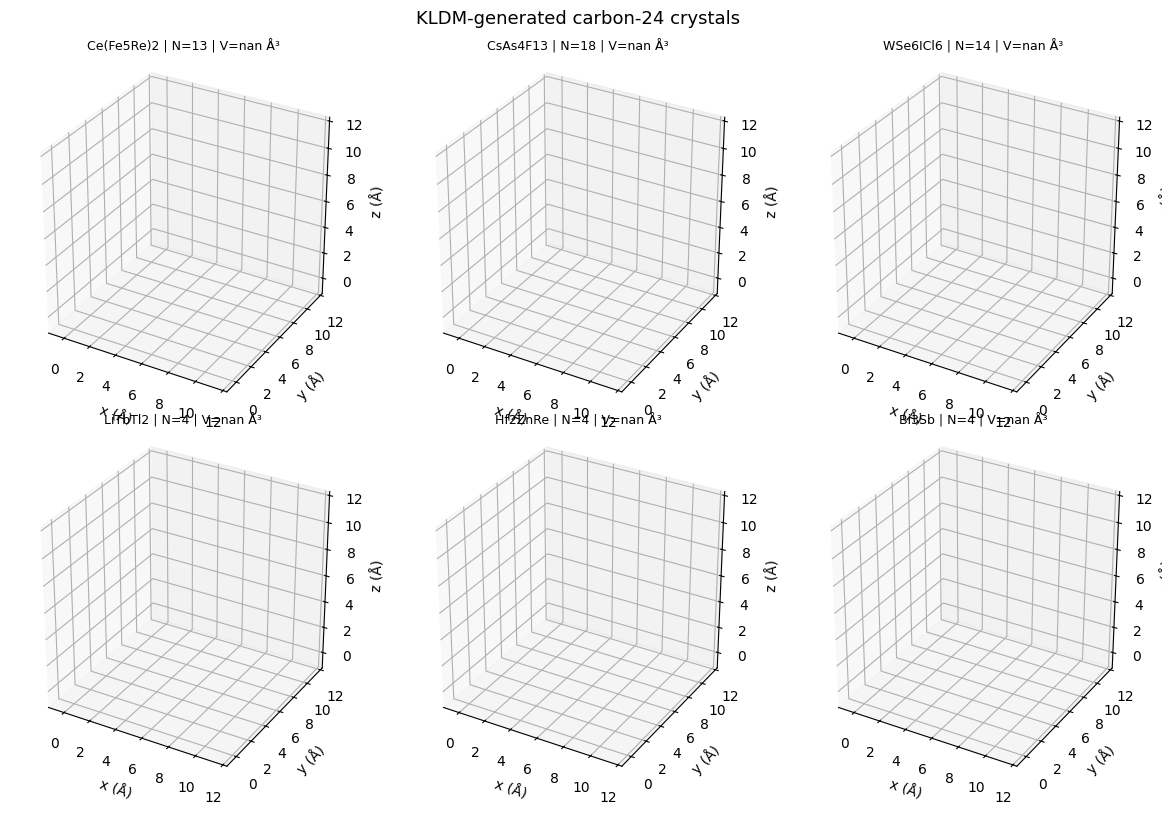

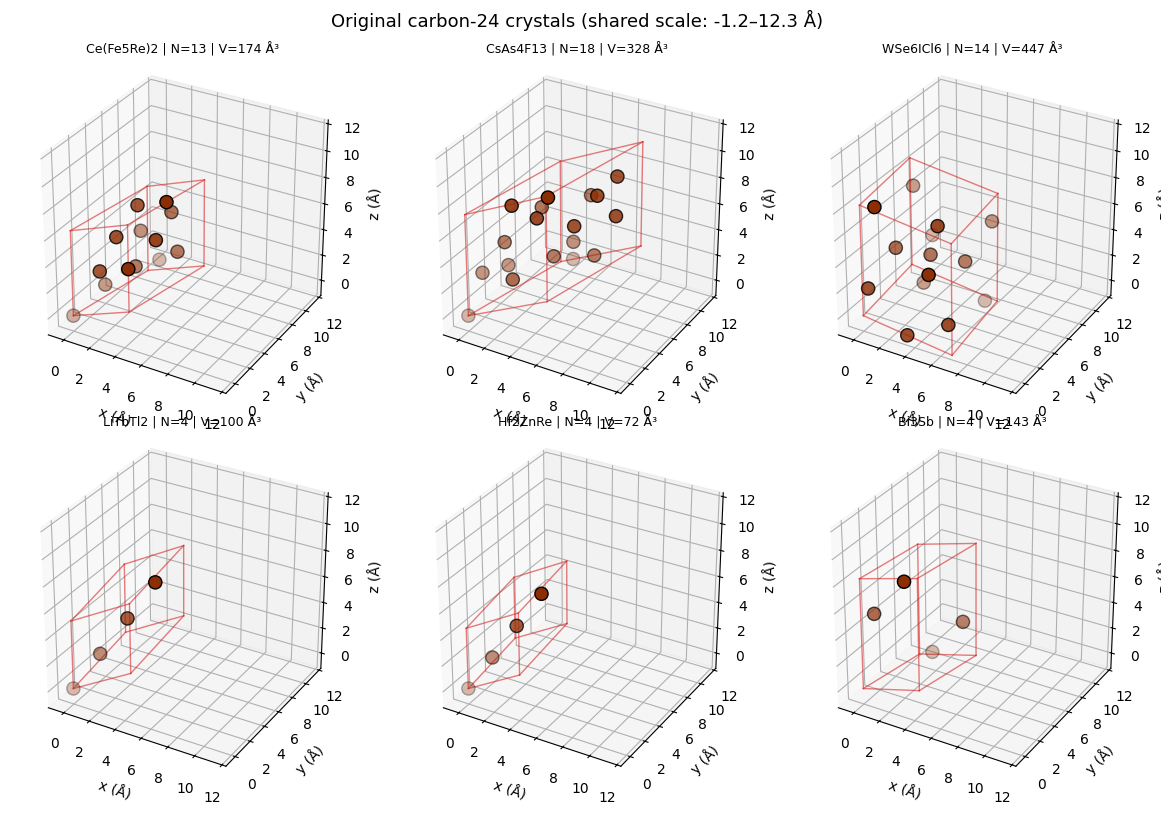

In [26]:
# ---- Plot the ORIGINAL carbon-24 crystals from the same template batch  ----
# ---- (graphT) used to seed generation, drawn with true Angstrom axes on  ----
# ---- a shared cubic scale so the physical size of the cells is visible.  ----
orig_structures = [PyGData_to_Structure(graphT[i], transform_lengths, transform_angles, transform_pos) for i in range(len(gen_structures))]


def _structure_bounds(structure):
    """Cartesian bounding box of the unit cell + atoms (min, max per axis)."""
    L = np.asarray(structure.lattice.matrix)
    verts = np.array([c[0] * L[0] + c[1] * L[1] + c[2] * L[2]
                      for c in itertools.product([0, 1], repeat=3)])
    pts = np.vstack([verts, np.asarray(structure.cart_coords)])
    return pts.min(axis=0), pts.max(axis=0)


_mins = np.array([_structure_bounds(s)[0] for s in orig_structures])
_maxs = np.array([_structure_bounds(s)[1] for s in orig_structures])
_lo, _hi = float(_mins.min()), float(_maxs.max())


def plot_structure_scaled(ax, structure, lo, hi, title=""):
    """Like plot_structure but keeps a shared, true Angstrom scale on the axes."""
    L = np.asarray(structure.lattice.matrix)
    coords = np.asarray(structure.cart_coords)
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               s=90, c="#8c2d04", edgecolors="k", depthshade=True)
    for a, b in _cell_edges(L):
        ax.plot(*zip(a, b), color="tab:red", lw=1.0, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_zlim(lo, hi)
    ax.set_box_aspect((1, 1, 1))

ncols = 3
nrows = (len(gen_structures) + ncols - 1) // ncols
fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
for i, s in enumerate(gen_structures):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
    plot_structure_scaled(ax, s, _lo, _hi, title=f"{s.composition.reduced_formula} | N={len(s)} | V={s.volume:.0f} Å³")
fig.suptitle("KLDM-generated carbon-24 crystals", fontsize=13)
fig.tight_layout()
plt.show()


ncols = 3
nrows = (len(orig_structures) + ncols - 1) // ncols
fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
for i, s in enumerate(orig_structures):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
    plot_structure_scaled(ax, s, _lo, _hi,
                          title=f"{s.composition.reduced_formula} | N={len(s)} | V={s.volume:.0f} Å³")
fig.suptitle(f"Original carbon-24 crystals (shared scale: {_lo:.1f}–{_hi:.1f} Å)", fontsize=13)
fig.tight_layout()
plt.show()

In [30]:
# Interactive 3D view of a single generated crystal (2x2x2 supercell to show
# the periodic packing). Change the index to inspect other samples.
from pymatgen.io.ase import AseAtomsAdaptor

sel = 1
print(gen_structures[sel])
atoms = AseAtomsAdaptor.get_atoms(gen_structures[sel])
print(atoms)
# atoms.pbc = True
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer

Full Formula (Cs1 As4 F13)
Reduced Formula: CsAs4F13
abc   :        inf        inf   0.000000
angles:        nan        nan        nan
pbc   :       True       True       True
Sites (18)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cs    0.838637  0.149792  0.93582
  1  As    0.272725  0.104347  0.279108
  2  As    0.771063  0.241192  0.093781
  3  As    0.502113  0.925099  0.944846
  4  As    0.445164  0.97901   0.902871
  5  F     0.464719  0.727105  0.348749
  6  F     0.643862  0.006287  0.890173
  7  F     0.919574  0.444547  0.780164
  8  F     0.148349  0.679775  0.154965
  9  F     0.585613  0.031482  0.515847
 10  F     0.188714  0.114012  0.672904
 11  F     0.572207  0.372077  0.261242
 12  F     0.498871  0.990354  0.03815
 13  F     0.82045   0.11282   0.355523
 14  F     0.075619  0.693089  0.584342
 15  F     0.591241  0.02117   0.265668
 16  F     0.129449  0.572279  0.871606
 17  F     0.676703  0.275959  0.364141
MSONAtoms(symbo

ValueError: cannot convert float NaN to integer